# Hard Rules Engine — Data Analysis

Validates and tunes the four deterministic rules in `helpers/rules_engine.py`.
For each rule we measure:
- **Precision** — of the transactions the rule blocks, what fraction are actual fraud?
- **Recall** — of all fraud in the dataset, what fraction does this rule catch?
- **Coverage** — what percentage of all transactions does the rule fire on?
- **FPR** — false-positive rate among legitimate transactions

Rules evaluated (in priority order, matching `HardRulesEngine.evaluate()`):
1. `BLACKLISTED_DEVICE` — device in external block set
2. `CARD_VELOCITY_1M` — ≥ 3 transactions on same card within 60 s
3. `CARD_VELOCITY_1H` — ≥ 10 transactions on same card within 3 600 s
4. `LARGE_AMOUNT_NEW_DEVICE` — amount > $500 on a first-seen device

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path

pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

DATA_PATH = Path('../data/ieee_prepared.pkl')
with open(DATA_PATH, 'rb') as f:
    raw = pickle.load(f)

train = raw['train']
val   = raw['val']

# hist = train + val, same as app.py's hist_raw  (test never used)
hist = pd.concat([train, val], ignore_index=True).sort_values('TransactionDT').reset_index(drop=True)

TOTAL    = len(hist)
N_FRAUD  = int(hist['isFraud'].sum())
N_LEGIT  = TOTAL - N_FRAUD
BASE_RATE = N_FRAUD / TOTAL

print(f'Dataset   : {TOTAL:,} transactions')
print(f'Fraud     : {N_FRAUD:,}  ({BASE_RATE:.3%})')
print(f'Legit     : {N_LEGIT:,}')
print(f'Cards     : {hist["card1"].nunique():,}  unique')
print(f'Devices   : {hist["DeviceInfo"].nunique():,}  unique  ({hist["DeviceInfo"].isna().mean():.1%} missing)')
print(f'Time span : {hist["TransactionDT"].min():,} → {hist["TransactionDT"].max():,} s')

Dataset   : 502,264 transactions
Fraud     : 17,594  (3.503%)
Legit     : 484,670
Cards     : 12,919  unique
Devices   : 1,681  unique  (79.4% missing)
Time span : 86,400 → 13,175,942 s


In [2]:
# ── Shared helpers ───────────────────────────────────────────────────────────

def rule_metrics(mask: pd.Series, label: str) -> dict:
    """Precision, recall, coverage, FPR for a boolean trigger mask."""
    triggered  = int(mask.sum())
    fraud_hit  = int((mask & (hist['isFraud'] == 1)).sum())
    precision  = fraud_hit / triggered if triggered else 0.0
    recall     = fraud_hit / N_FRAUD   if N_FRAUD   else 0.0
    coverage   = triggered / TOTAL
    fpr        = (triggered - fraud_hit) / N_LEGIT
    return dict(
        rule=label, triggered=triggered, fraud_caught=fraud_hit,
        precision=round(precision, 4), recall=round(recall, 4),
        coverage=round(coverage, 4),   fpr=round(fpr, 6),
    )


def threshold_sweep(masks_by_threshold: dict, ax, xlabel: str):
    """Plot precision and recall vs a threshold on a shared axis."""
    thresholds  = sorted(masks_by_threshold)
    precisions, recalls, coverages = [], [], []
    for t in thresholds:
        m = masks_by_threshold[t]
        n   = m.sum()
        hit = (m & (hist['isFraud'] == 1)).sum()
        precisions.append(hit / n   if n else 0.0)
        recalls.append(   hit / N_FRAUD)
        coverages.append(  n / TOTAL)

    ax2 = ax.twinx()
    ax.plot(thresholds, precisions, 'o-', color='#2196F3', label='Precision')
    ax.plot(thresholds, recalls,    's-', color='#F44336', label='Recall')
    ax2.plot(thresholds, coverages, '^--', color='#9E9E9E', label='Coverage')

    ax.set_xlabel(xlabel)
    ax.set_ylabel('Precision / Recall')
    ax2.set_ylabel('Coverage (% of all txns)', color='#9E9E9E')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    return precisions, recalls, coverages

---
## Rules 1 & 2 — Card Velocity

**Rule 1 (`CARD_VELOCITY_1M`)**: block when ≥ 3 prior transactions on the same card in the last 60 seconds.  
**Rule 2 (`CARD_VELOCITY_1H`)**: block when ≥ 10 prior transactions on the same card in the last 3 600 seconds.

Computation: for each transaction we count strictly-prior transactions (same card, earlier timestamp) within the window using `numpy.searchsorted` on the time-sorted group — O(N log N) total.

In [3]:
def velocity_counts(times: np.ndarray, window: int) -> np.ndarray:
    """
    For each row i (times must be sorted ascending), return the count of
    prior rows j < i where times[j] >= times[i] - window.
    Matches the logic in HardRulesEngine._rule_card_velocity().
    """
    lo  = np.searchsorted(times, times - window, side='left')
    idx = np.arange(len(times))
    return idx - lo   # strictly prior entries in [lo, i-1]


# Sort by card1 then time so searchsorted works within each group
vel = hist[['TransactionDT', 'card1', 'isFraud']].copy()
vel = vel.sort_values(['card1', 'TransactionDT']).reset_index(drop=True)

print('Computing 1-min velocity…')
vel['prior_1m'] = (
    vel.groupby('card1', sort=False)['TransactionDT']
       .transform(lambda t: velocity_counts(t.values, 60))
)

print('Computing 1-hour velocity…')
vel['prior_1h'] = (
    vel.groupby('card1', sort=False)['TransactionDT']
       .transform(lambda t: velocity_counts(t.values, 3600))
)

print('Done.')
print('\nVelocity statistics:')
display(vel[['prior_1m', 'prior_1h']].describe())

# Configured thresholds
MAX_TXNS_PER_MINUTE = 3
MAX_TXNS_PER_HOUR   = 10

mask_vel_1m = vel['prior_1m'] >= MAX_TXNS_PER_MINUTE
mask_vel_1h = vel['prior_1h'] >= MAX_TXNS_PER_HOUR

Computing 1-min velocity…
Computing 1-hour velocity…
Done.

Velocity statistics:


,prior_1m,prior_1h
count,502264.0000,502264.0000
mean,0.0340,1.3048
std,0.1995,3.2056
min,0.0000,0.0000
25%,0.0000,0.0000
50%,0.0000,0.0000
75%,0.0000,1.0000
max,11.0000,68.0000


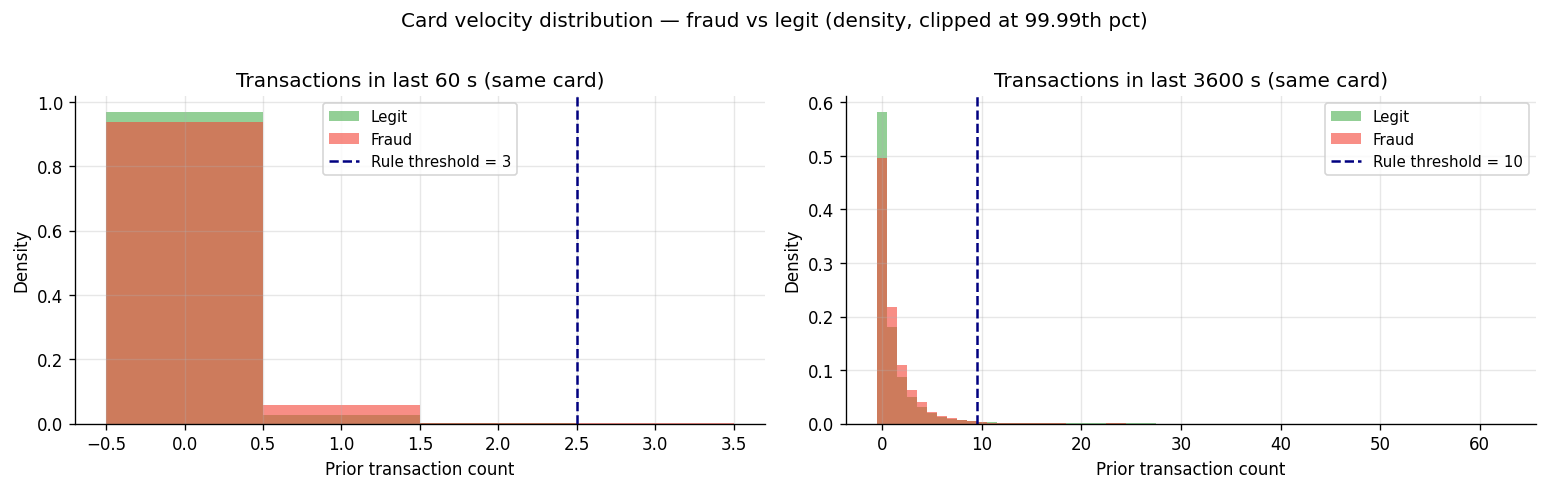

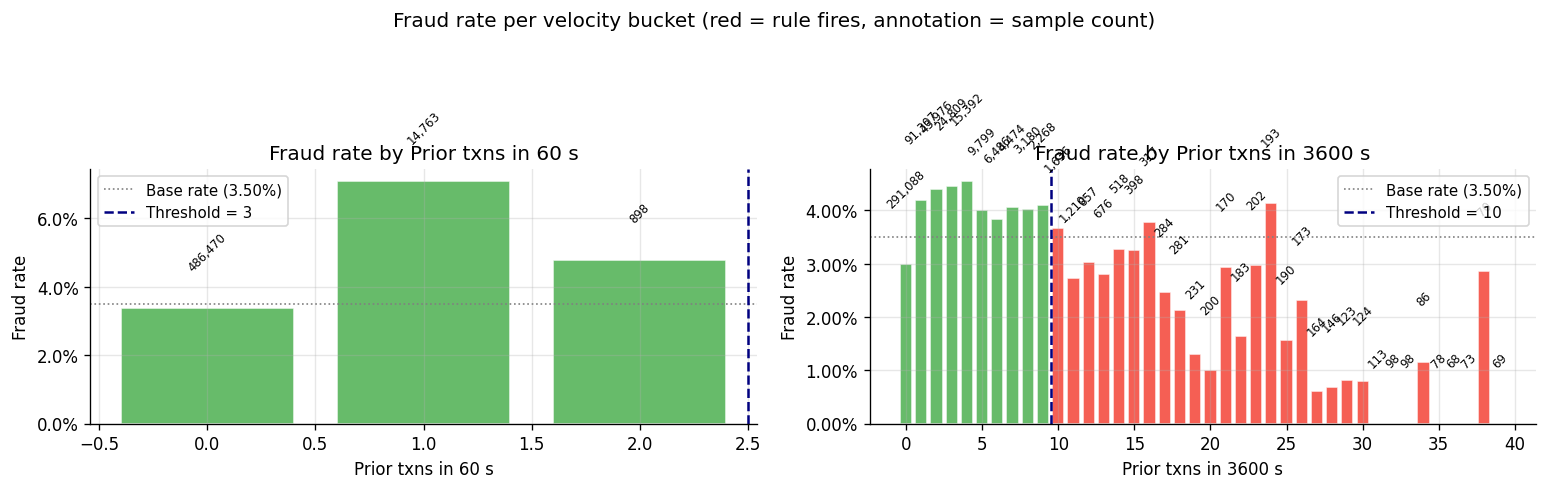

In [4]:
# ── Distribution: velocity value by fraud / legit ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, title, configured_thresh in [
    (axes[0], 'prior_1m', 'Transactions in last 60 s (same card)', MAX_TXNS_PER_MINUTE),
    (axes[1], 'prior_1h', 'Transactions in last 3600 s (same card)', MAX_TXNS_PER_HOUR),
]:
    max_val = int(vel[col].quantile(0.9999))
    bins    = np.arange(0, max_val + 2) - 0.5

    legit_vals = vel.loc[vel['isFraud'] == 0, col].clip(upper=max_val)
    fraud_vals = vel.loc[vel['isFraud'] == 1, col].clip(upper=max_val)

    ax.hist(legit_vals, bins=bins, density=True, alpha=0.6, color='#4CAF50', label='Legit')
    ax.hist(fraud_vals, bins=bins, density=True, alpha=0.6, color='#F44336', label='Fraud')
    ax.axvline(configured_thresh - 0.5, color='navy', lw=1.5, ls='--',
               label=f'Rule threshold = {configured_thresh}')
    ax.set_title(title)
    ax.set_xlabel('Prior transaction count')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.suptitle('Card velocity distribution — fraud vs legit (density, clipped at 99.99th pct)', y=1.01)
plt.tight_layout()
plt.show()

# Fraud rate BY velocity bucket
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, xlabel, thresh in [
    (axes[0], 'prior_1m', 'Prior txns in 60 s', MAX_TXNS_PER_MINUTE),
    (axes[1], 'prior_1h', 'Prior txns in 3600 s', MAX_TXNS_PER_HOUR),
]:
    max_bucket = int(vel[col].quantile(0.999))
    buckets = range(0, max_bucket + 1)
    fraud_rates = [
        vel.loc[vel[col] == b, 'isFraud'].mean() for b in buckets
    ]
    counts = [int((vel[col] == b).sum()) for b in buckets]

    color = ['#F44336' if b >= thresh else '#4CAF50' for b in buckets]
    bars = ax.bar(list(buckets), fraud_rates, color=color, edgecolor='white', alpha=0.85)
    ax.axhline(BASE_RATE, color='grey', lw=1, ls=':', label=f'Base rate ({BASE_RATE:.2%})')
    ax.axvline(thresh - 0.5, color='navy', lw=1.5, ls='--', label=f'Threshold = {thresh}')

    # Annotate counts on bars
    for b, cnt in zip(buckets, counts):
        if cnt > 0:
            ax.text(b, fraud_rates[b] + 0.01, f'{cnt:,}', ha='center', va='bottom', fontsize=7, rotation=45)

    ax.set_title(f'Fraud rate by {xlabel}')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Fraud rate')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.legend(fontsize=9)

plt.suptitle('Fraud rate per velocity bucket (red = rule fires, annotation = sample count)', y=1.01)
plt.tight_layout()
plt.show()

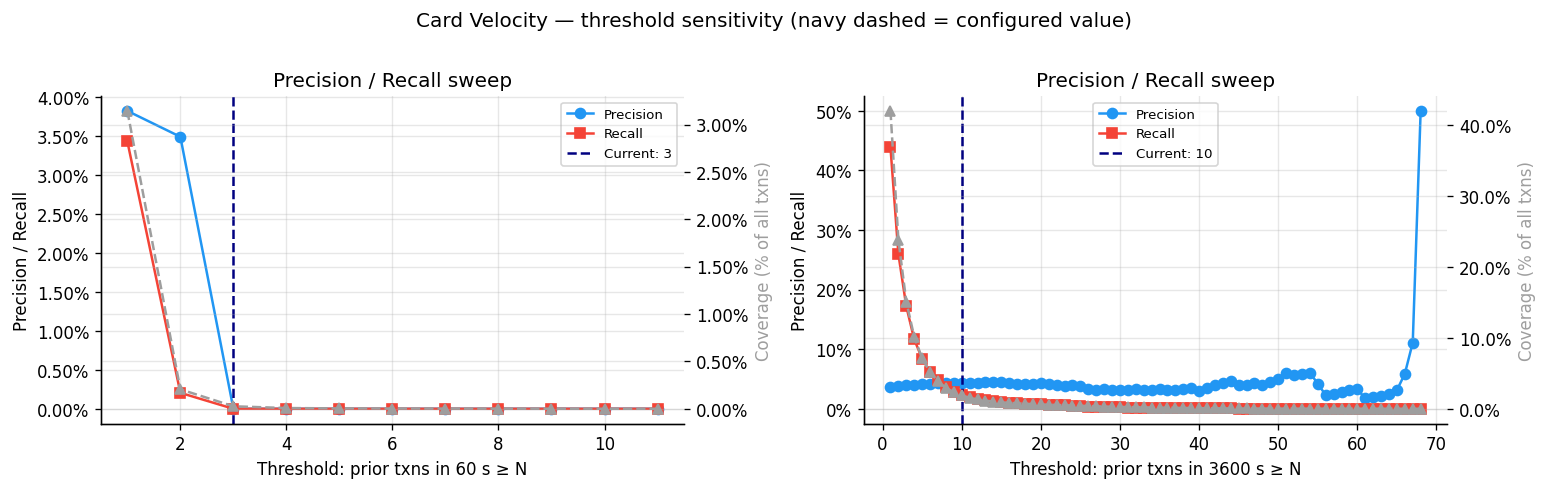


Metrics at configured thresholds:


,triggered,fraud_caught,precision,recall,coverage,fpr
rule,,,,,,
CARD_VELOCITY_1M,133,0,0.0000,0.0000,0.0003,0.0003
CARD_VELOCITY_1H,9485,415,0.0438,0.0236,0.0189,0.0187


In [5]:
# ── Threshold sensitivity sweep ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, label, configured_thresh in [
    (axes[0], 'prior_1m', 'Threshold: prior txns in 60 s ≥ N', MAX_TXNS_PER_MINUTE),
    (axes[1], 'prior_1h', 'Threshold: prior txns in 3600 s ≥ N', MAX_TXNS_PER_HOUR),
]:
    max_t = max(int(vel[col].max()), configured_thresh + 3)
    thresholds = {t: (vel[col] >= t) for t in range(1, max_t + 1)}
    threshold_sweep(thresholds, ax, label)
    ax.axvline(configured_thresh, color='navy', lw=1.5, ls='--', label=f'Current: {configured_thresh}')
    ax.legend(fontsize=8)
    ax.set_title(f'Precision / Recall sweep')

plt.suptitle('Card Velocity — threshold sensitivity (navy dashed = configured value)', y=1.01)
plt.tight_layout()
plt.show()

# Print metrics at the configured thresholds
m1 = rule_metrics(mask_vel_1m, 'CARD_VELOCITY_1M')
m2 = rule_metrics(mask_vel_1h, 'CARD_VELOCITY_1H')
print('\nMetrics at configured thresholds:')
display(pd.DataFrame([m1, m2]).set_index('rule'))

---
## Rule 3 — Large Amount + New Device

Blocks transactions where **DeviceInfo has never been seen before** (in temporal order)
and the **transaction amount exceeds $500**.

Note: DeviceInfo is missing for ~78% of rows. Missing-device transactions are excluded from
this rule (same as `rules_engine.py` — the rule returns `no_hit` when `DeviceInfo` is `NaN`).

In [6]:
AMOUNT_LIMIT = 500.0

# The dataset is already sorted by TransactionDT (we did that above).
# First occurrence of a DeviceInfo = 'new device' at that point in time.
dev = hist[['TransactionDT', 'DeviceInfo', 'TransactionAmt', 'isFraud']].copy()

# Mark each device's first appearance (chronological order, NaN excluded)
dev['is_new_device'] = (~dev['DeviceInfo'].duplicated(keep='first')) & dev['DeviceInfo'].notna()

mask_new_device_large = dev['is_new_device'] & (dev['TransactionAmt'] > AMOUNT_LIMIT)

# Summary
new_device_mask = dev['is_new_device']
print(f"Transactions with known DeviceInfo : {dev['DeviceInfo'].notna().sum():>8,}")
print(f"First appearances (new device)     : {new_device_mask.sum():>8,}")
print(f"  … with amount > ${AMOUNT_LIMIT:.0f}            : {mask_new_device_large.sum():>8,}")
print()
print('Fraud rate breakdown:')
for label, mask in [
    ('All transactions',                              pd.Series([True]*TOTAL)),
    ('Known device (DeviceInfo not null)',            dev['DeviceInfo'].notna()),
    ('First-seen device',                            new_device_mask),
    (f'First-seen device + amt > ${AMOUNT_LIMIT:.0f}', mask_new_device_large),
    ('Returning device',                             dev['DeviceInfo'].notna() & ~new_device_mask),
]:
    sub = dev.loc[mask, 'isFraud']
    print(f"  {label:45s}: {sub.mean():.3%}  (n={len(sub):,})")

Transactions with known DeviceInfo :  103,602
First appearances (new device)     :    1,681
  … with amount > $500            :        0

Fraud rate breakdown:
  All transactions                             : 3.503%  (n=502,264)
  Known device (DeviceInfo not null)           : 6.982%  (n=103,602)
  First-seen device                            : 5.770%  (n=1,681)
  First-seen device + amt > $500               : nan%  (n=0)
  Returning device                             : 7.002%  (n=101,921)


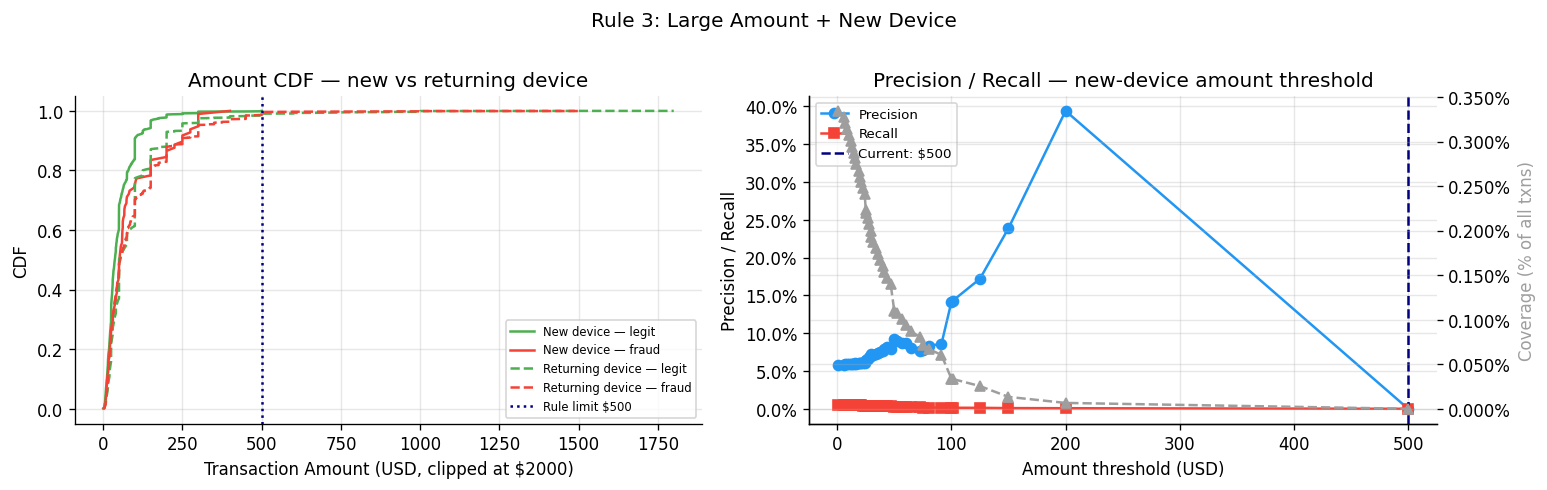


Metrics at configured threshold:


,triggered,fraud_caught,precision,recall,coverage,fpr
rule,,,,,,
LARGE_AMOUNT_NEW_DEVICE,0,0,0.0000,0.0000,0.0000,0.0000


In [7]:
# ── Amount distribution: new vs returning devices ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: amount CDF for new vs returning device, split by fraud label
ax = axes[0]
for label, mask, color, ls in [
    ('New device — legit',     dev['is_new_device'] & (dev['isFraud'] == 0), '#4CAF50', '-'),
    ('New device — fraud',     dev['is_new_device'] & (dev['isFraud'] == 1), '#F44336', '-'),
    ('Returning device — legit', dev['DeviceInfo'].notna() & ~dev['is_new_device'] & (dev['isFraud'] == 0), '#4CAF50', '--'),
    ('Returning device — fraud', dev['DeviceInfo'].notna() & ~dev['is_new_device'] & (dev['isFraud'] == 1), '#F44336', '--'),
]:
    vals = dev.loc[mask, 'TransactionAmt'].clip(upper=2000)
    if len(vals) < 5:
        continue
    sorted_vals = np.sort(vals)
    cdf = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)
    ax.plot(sorted_vals, cdf, color=color, ls=ls, lw=1.5, label=label)

ax.axvline(AMOUNT_LIMIT, color='navy', lw=1.5, ls=':', label=f'Rule limit ${AMOUNT_LIMIT:.0f}')
ax.set_xlabel('Transaction Amount (USD, clipped at $2000)')
ax.set_ylabel('CDF')
ax.set_title('Amount CDF — new vs returning device')
ax.legend(fontsize=7)

# Right: fraud rate vs amount threshold (for new-device txns only)
ax = axes[1]
thresholds = np.percentile(dev.loc[dev['is_new_device'], 'TransactionAmt'], np.arange(0, 99, 2))
thresholds = np.unique(np.concatenate([thresholds, [AMOUNT_LIMIT]]))

masks_by_t = {t: (dev['is_new_device'] & (dev['TransactionAmt'] > t)) for t in thresholds}
threshold_sweep(masks_by_t, ax, 'Amount threshold (USD)')
ax.axvline(AMOUNT_LIMIT, color='navy', lw=1.5, ls='--', label=f'Current: ${AMOUNT_LIMIT:.0f}')
ax.legend(fontsize=8)
ax.set_title('Precision / Recall — new-device amount threshold')

plt.suptitle('Rule 3: Large Amount + New Device', y=1.01)
plt.tight_layout()
plt.show()

m3 = rule_metrics(mask_new_device_large, 'LARGE_AMOUNT_NEW_DEVICE')
print('\nMetrics at configured threshold:')
display(pd.DataFrame([m3]).set_index('rule'))

---
## Rule 4 — Blacklisted Device

In production the blacklist is externally managed (confirmed fraud devices, partner feeds, etc.).
Here we analyze what device-level fraud rates look like in the dataset to understand
which devices *would* earn a blacklist entry, and what precision/recall a top-K blacklist achieves.

Only devices with ≥ 5 historical transactions are included to avoid noisy rate estimates.

In [8]:
device_stats = (
    hist[hist['DeviceInfo'].notna()]
    .groupby('DeviceInfo')
    .agg(
        total      =('isFraud', 'count'),
        fraud      =('isFraud', 'sum'),
        avg_amount =('TransactionAmt', 'mean'),
    )
    .assign(fraud_rate=lambda d: d['fraud'] / d['total'])
    .query('total >= 5')
    .sort_values('fraud_rate', ascending=False)
    .reset_index()
)

print(f'Devices with ≥ 5 transactions: {len(device_stats):,}')
print(f'\nTop 15 highest-fraud-rate devices:')
display(device_stats.head(15)[['DeviceInfo','total','fraud','fraud_rate','avg_amount']])

Devices with ≥ 5 transactions: 789

Top 15 highest-fraud-rate devices:


,DeviceInfo,total,fraud,fraud_rate,avg_amount
0,SM-G925T Build/LMY47X,6,6,1.0000,56.9767
1,Nexus 6 Build/MOB30M,11,11,1.0000,81.7208
2,Alcatel_4060O Build/MMB29M,5,5,1.0000,270.0000
3,Z813 Build/LMY47O,11,11,1.0000,21.3555
4,XT890 Build/9.8.2I-50_SML-25,8,8,1.0000,8.5190
5,Ilium Pad T7X Build/LMY47I,5,5,1.0000,25.7996
6,SM-N920A Build/MMB29K,21,21,1.0000,40.0907
7,A574BL Build/NMF26F,6,6,1.0000,158.3333
8,VS5012 Build/NRD90M,34,34,1.0000,21.8666
9,Z835 Build/NMF26V,17,17,1.0000,192.6471


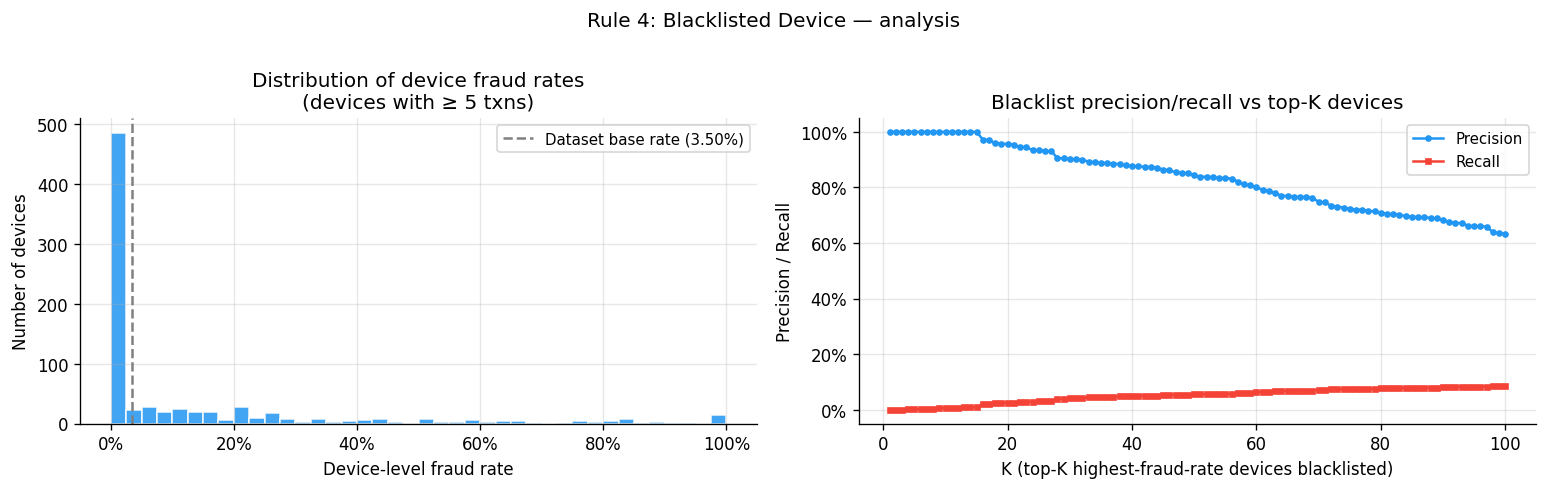


Simulated blacklist: 69 devices with fraud rate ≥ 50%


,triggered,fraud_caught,precision,recall,coverage,fpr
rule,,,,,,
BLACKLISTED_DEVICE (fraud_rate≥50%),1596,1218,0.7632,0.0692,0.0032,0.0008


In [9]:
# ── Blacklist simulation: top-K by fraud rate ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: fraud-rate distribution across devices
ax = axes[0]
ax.hist(device_stats['fraud_rate'], bins=40, color='#2196F3', edgecolor='white', alpha=0.85)
ax.axvline(BASE_RATE, color='grey', lw=1.5, ls='--', label=f'Dataset base rate ({BASE_RATE:.2%})')
ax.set_xlabel('Device-level fraud rate')
ax.set_ylabel('Number of devices')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Distribution of device fraud rates\n(devices with ≥ 5 txns)')
ax.legend(fontsize=9)

# Right: precision/recall of blacklisting top-K devices
ax = axes[1]
k_values = range(1, min(101, len(device_stats) + 1))
precisions_k, recalls_k = [], []

for k in k_values:
    bl_devices = set(device_stats.head(k)['DeviceInfo'])
    bl_mask = hist['DeviceInfo'].isin(bl_devices)
    n   = bl_mask.sum()
    hit = (bl_mask & (hist['isFraud'] == 1)).sum()
    precisions_k.append(hit / n   if n   else 0.0)
    recalls_k.append(   hit / N_FRAUD)

ax.plot(list(k_values), precisions_k, 'o-', ms=3, color='#2196F3', label='Precision')
ax.plot(list(k_values), recalls_k,    's-', ms=3, color='#F44336', label='Recall')
ax.set_xlabel('K (top-K highest-fraud-rate devices blacklisted)')
ax.set_ylabel('Precision / Recall')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Blacklist precision/recall vs top-K devices')
ax.legend(fontsize=9)

plt.suptitle('Rule 4: Blacklisted Device — analysis', y=1.01)
plt.tight_layout()
plt.show()

# Simulate blacklisting devices with fraud_rate > 50% and >= 5 txns
high_fraud_devices = set(device_stats.loc[device_stats['fraud_rate'] >= 0.5, 'DeviceInfo'])
mask_blacklist = hist['DeviceInfo'].isin(high_fraud_devices)
m4 = rule_metrics(mask_blacklist, 'BLACKLISTED_DEVICE (fraud_rate≥50%)')
print(f'\nSimulated blacklist: {len(high_fraud_devices)} devices with fraud rate ≥ 50%')
display(pd.DataFrame([m4]).set_index('rule'))

---
## Combined Rule Coverage

Rules run in the priority order defined in `HardRulesEngine.evaluate()`.  
Each rule only captures transactions **not already blocked by a higher-priority rule**.

The waterfall below shows the incremental fraud catch for each rule.

In [10]:
# Re-align all masks onto hist index (vel was re-sorted, so re-derive from hist order)
hist_sorted_card = hist.sort_values(['card1', 'TransactionDT'])
prior_1m = hist_sorted_card.groupby('card1', sort=False)['TransactionDT'].transform(
    lambda t: velocity_counts(t.values, 60)
)
prior_1h = hist_sorted_card.groupby('card1', sort=False)['TransactionDT'].transform(
    lambda t: velocity_counts(t.values, 3600)
)
# Restore to hist order
prior_1m = prior_1m.reindex(hist.index)
prior_1h = prior_1h.reindex(hist.index)

# Priority-gated masks (each rule only fires on un-blocked transactions)
blocked = pd.Series(False, index=hist.index)

mask_r4_indep  = hist['DeviceInfo'].isin(high_fraud_devices)           # Rule 4 (simulated)
mask_r1_indep  = prior_1m >= MAX_TXNS_PER_MINUTE                        # Rule 1
mask_r2_indep  = prior_1h >= MAX_TXNS_PER_HOUR                          # Rule 2
mask_r3_indep  = mask_new_device_large.reindex(hist.index, fill_value=False)  # Rule 3

waterfall_rows = []
for label, mask_indep in [
    ('BLACKLISTED_DEVICE',      mask_r4_indep),
    ('CARD_VELOCITY_1M',        mask_r1_indep),
    ('CARD_VELOCITY_1H',        mask_r2_indep),
    ('LARGE_AMOUNT_NEW_DEVICE', mask_r3_indep),
]:
    incremental = mask_indep & ~blocked
    blocked     = blocked | incremental
    m = rule_metrics(incremental, label + ' (incremental)')
    waterfall_rows.append(m)

# Totals
total_blocked    = int(blocked.sum())
total_fraud_hit  = int((blocked & (hist['isFraud'] == 1)).sum())
total_legit_hit  = total_blocked - total_fraud_hit
overall_recall   = total_fraud_hit / N_FRAUD
overall_precision = total_fraud_hit / total_blocked if total_blocked else 0

print('Waterfall: incremental fraud catch per rule (in priority order)\n')
wf = pd.DataFrame(waterfall_rows).set_index('rule')
display(wf)

print(f'\n─────────────────────────────────────────────')
print(f'Combined (any rule)  : {total_blocked:,} blocked')
print(f'  Fraud blocked      : {total_fraud_hit:,}  ({overall_recall:.2%} recall)')
print(f'  Legit blocked (FP) : {total_legit_hit:,}')
print(f'  Combined precision : {overall_precision:.2%}')
print(f'  Transactions passing all rules → ML: {TOTAL - total_blocked:,}  ({(TOTAL-total_blocked)/TOTAL:.1%})')

Waterfall: incremental fraud catch per rule (in priority order)



,triggered,fraud_caught,precision,recall,coverage,fpr
rule,,,,,,
BLACKLISTED_DEVICE (incremental),1596,1218,0.7632,0.0692,0.0032,0.0008
CARD_VELOCITY_1M (incremental),132,17,0.1288,0.0010,0.0003,0.0002
CARD_VELOCITY_1H (incremental),9397,221,0.0235,0.0126,0.0187,0.0189
LARGE_AMOUNT_NEW_DEVICE (incremental),0,0,0.0000,0.0000,0.0000,0.0000



─────────────────────────────────────────────
Combined (any rule)  : 11,125 blocked
  Fraud blocked      : 1,456  (8.28% recall)
  Legit blocked (FP) : 9,669
  Combined precision : 13.09%
  Transactions passing all rules → ML: 491,139  (97.8%)


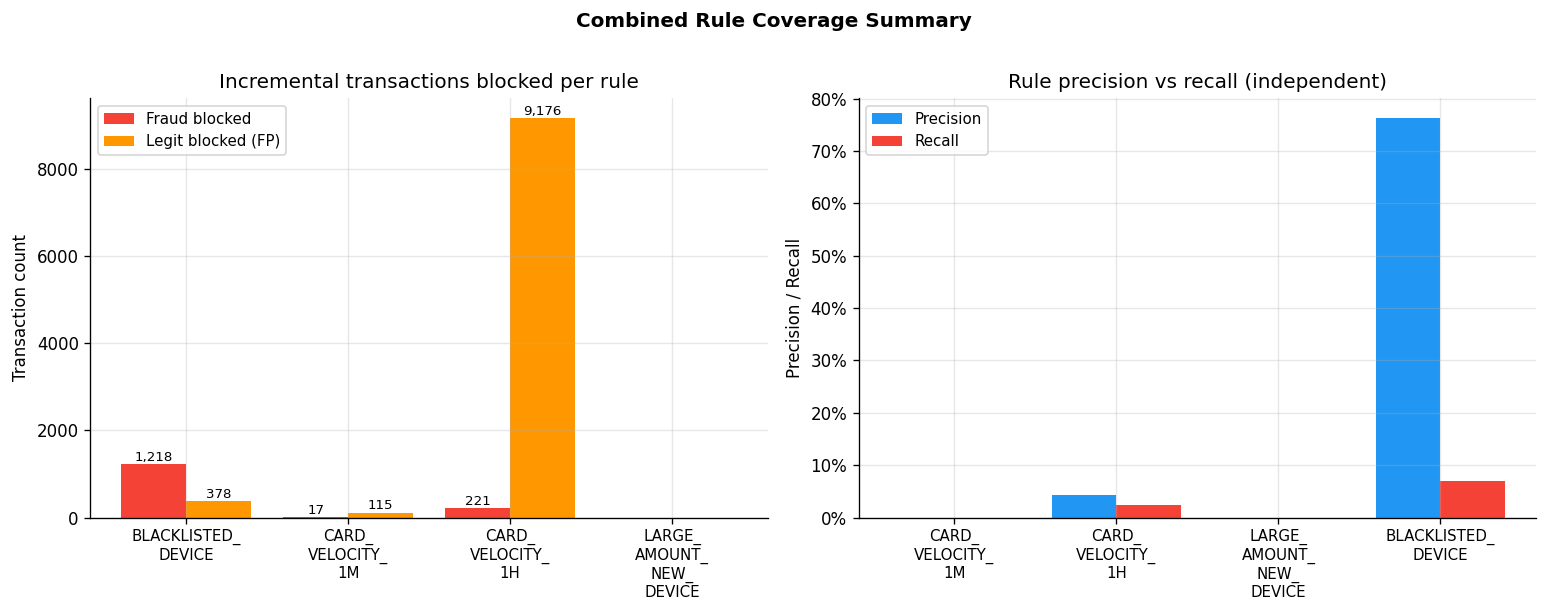


All rules — independent metrics (not priority-gated):


,triggered,fraud_caught,precision,recall,coverage,fpr
rule,,,,,,
CARD_VELOCITY_1M,133,0,0.0%,0.0%,0.03%,0.0274%
CARD_VELOCITY_1H,9485,415,4.4%,2.4%,1.89%,1.8714%
LARGE_AMOUNT_NEW_DEVICE,0,0,0.0%,0.0%,0.00%,0.0000%
BLACKLISTED_DEVICE,1596,1218,76.3%,6.9%,0.32%,0.0780%


In [11]:
# ── Waterfall bar chart ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

rule_labels = [r['rule'].replace(' (incremental)', '').replace('_', '_\n') for r in waterfall_rows]
fraud_caught = [r['fraud_caught'] for r in waterfall_rows]
legit_blocked = [r['triggered'] - r['fraud_caught'] for r in waterfall_rows]

x = np.arange(len(rule_labels))
width = 0.4

ax = axes[0]
bars_f = ax.bar(x - width/2, fraud_caught,  width, color='#F44336', label='Fraud blocked')
bars_l = ax.bar(x + width/2, legit_blocked, width, color='#FF9800', label='Legit blocked (FP)')
ax.set_xticks(x)
ax.set_xticklabels(rule_labels, fontsize=9)
ax.set_ylabel('Transaction count')
ax.set_title('Incremental transactions blocked per rule')
ax.legend(fontsize=9)

# Annotate totals on bars
for bar in list(bars_f) + list(bars_l):
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 5, f'{h:,}',
                ha='center', va='bottom', fontsize=8)

# Right: precision/recall per rule (independent, not incremental)
ax = axes[1]
all_metrics = [m1, m2, m3, rule_metrics(mask_blacklist, 'BLACKLISTED_DEVICE')]
labels_r    = [m['rule'] for m in all_metrics]
precs       = [m['precision'] for m in all_metrics]
recs        = [m['recall'] for m in all_metrics]

x2 = np.arange(len(labels_r))
ax.bar(x2 - width/2, precs, width, color='#2196F3', label='Precision')
ax.bar(x2 + width/2, recs,  width, color='#F44336', label='Recall')
ax.set_xticks(x2)
ax.set_xticklabels([l.replace('_',  '_\n') for l in labels_r], fontsize=9)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylabel('Precision / Recall')
ax.set_title('Rule precision vs recall (independent)')
ax.legend(fontsize=9)

plt.suptitle('Combined Rule Coverage Summary', y=1.01, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary table: all rules independent
print('\nAll rules — independent metrics (not priority-gated):')
display(
    pd.DataFrame(all_metrics)
    .set_index('rule')
    .style.background_gradient(subset=['precision','recall'], cmap='RdYlGn')
    .format({'precision': '{:.1%}', 'recall': '{:.1%}', 'coverage': '{:.2%}', 'fpr': '{:.4%}'})
)